In [18]:
import lightkurve
import matplotlib.pyplot as plot
import numpy
import triceratops.triceratops as tr
import json

from lightkurve.correctors import PLDCorrector

%matplotlib inline
# plot.style.use('seaborn-v0_8')
parent_folder = 'CTOI Creation'

In [2]:
data_paths = []

with open(f'{parent_folder}/queue_data_paths.txt', 'r+') as file:
    data_paths.extend([file_name.strip() for file_name in file.readlines()])
    file.seek(0)

data_paths

[]

In [3]:
data_path = data_paths[0]
data_path

IndexError: list index out of range

In [ ]:
with open(data_path, 'r') as file:
    data = json.load(file)

data

In [58]:
data = {
    'id_num': 235060821,
    'triceratops': {
        'period': None,
        'transit_duration': 14,
        'transit_time': 1507.5,
        'transit_depth': 0.0004
    }
}

In [7]:
star_id = data['id_num']
star_id

235060821

In [8]:
triceratops = data['triceratops']
triceratops

{'period': None,
 'transit_duration': 14,
 'transit_time': 1507.5,
 'transit_depth': 0.0004}

In [9]:
search_result = lightkurve.search_lightcurve(f'TIC {star_id}', mission = 'TESS')[:20]
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 06,2018,SPOC,120,235060821,0.0
1,TESS Sector 05,2018,SPOC,120,235060821,0.0
2,TESS Sector 04,2018,SPOC,120,235060821,0.0
3,TESS Sector 07,2019,SPOC,120,235060821,0.0
4,TESS Sector 33,2020,SPOC,120,235060821,0.0
5,TESS Sector 32,2020,SPOC,120,235060821,0.0
6,TESS Sector 31,2020,SPOC,120,235060821,0.0
7,TESS Sector 27,2020,SPOC,120,235060821,0.0
8,TESS Sector 37,2021,SPOC,120,235060821,0.0


In [15]:
lc = search_result[3].download_all().stitch()
lc

time,flux,flux_err,timecorr,cadenceno,centroid_col,centroid_row,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,,,d,,pix,pix,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,float32,int32,float64,float64,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
1491.6399883157058,———,———,1.2712874e-03,190212,1902.91568,174.85239,7.7568289e+04,3.2220276e+01,5.8038193e+03,9.5819492e+00,———,———,1000000000000000,———,———,———,———,1902.91568,3.5154232e-04,174.85239,3.5244707e-04,4.6730369e-02,-1.8116152e-01
1491.6413771879497,———,———,1.2712714e-03,190213,1902.91467,174.84931,7.7588023e+04,3.2217590e+01,5.7801313e+03,9.5726786e+00,———,———,1000000000000000,———,———,———,———,1902.91467,3.5108006e-04,174.84931,3.5215856e-04,4.5718413e-02,-1.8392289e-01
1491.6427660601946,———,———,1.2712553e-03,190214,1902.91408,174.84874,7.7545742e+04,3.2206486e+01,5.7534609e+03,9.5579834e+00,———,———,1000000000000000,———,———,———,———,1902.91408,3.5124959e-04,174.84874,3.5266962e-04,4.5713473e-02,-1.8492229e-01
1491.64415493244,———,———,1.2712392e-03,190215,1902.91631,174.84951,7.7644562e+04,3.2208961e+01,5.7316313e+03,9.5397215e+00,———,———,1000000000000000,———,———,———,———,1902.91631,3.5063789e-04,174.84951,3.5198068e-04,4.6088323e-02,-1.8374473e-01
1491.6455438046848,———,———,1.2712232e-03,190216,1902.90813,174.84383,7.7528445e+04,3.2187420e+01,5.7289629e+03,9.5367718e+00,———,———,1000000000000000,———,———,———,———,1902.90813,3.5098565e-04,174.84383,3.5264829e-04,3.8937584e-02,-1.9005257e-01
1491.6469326769297,———,———,1.2712071e-03,190217,1902.91767,174.85735,7.7580578e+04,3.2195457e+01,5.7153594e+03,9.5297537e+00,———,———,1000000000000000,———,———,———,———,1902.91767,3.5044239e-04,174.85735,3.5184639e-04,4.8119839e-02,-1.7589675e-01
1491.6483215491744,———,———,1.2711911e-03,190218,1902.91505,174.85533,7.7601055e+04,3.2182365e+01,5.6804082e+03,9.5041370e+00,———,———,1000000000000000,———,———,———,———,1902.91505,3.5050718e-04,174.85533,3.5126376e-04,4.5823131e-02,-1.7670104e-01
1491.6497104214186,———,———,1.2711750e-03,190219,1902.91797,174.86031,7.7559695e+04,3.2174625e+01,5.6727041e+03,9.4980211e+00,———,———,1000000000000000,———,———,———,———,1902.91797,3.5043308e-04,174.86031,3.5147442e-04,4.9088012e-02,-1.7243351e-01


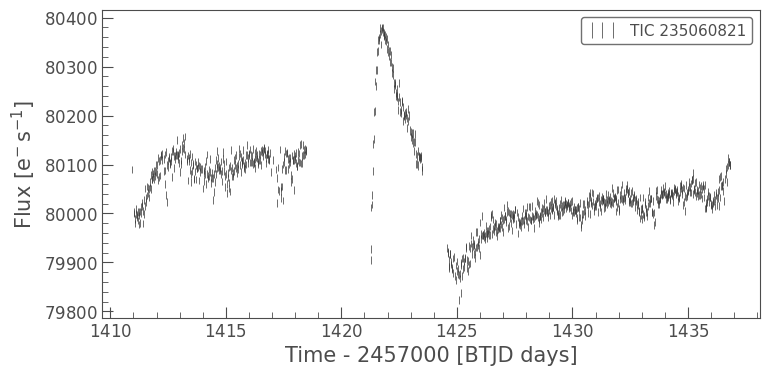

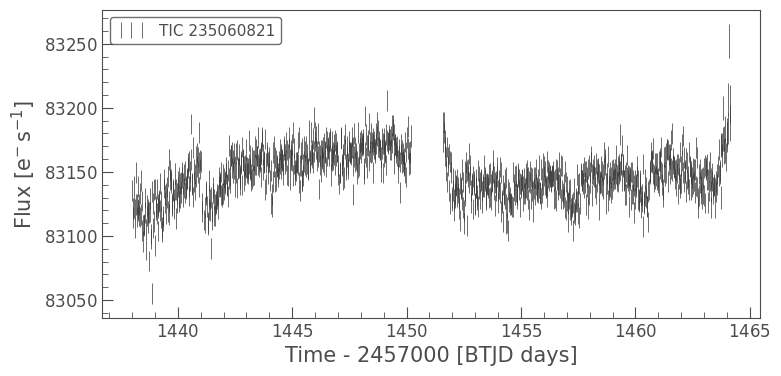

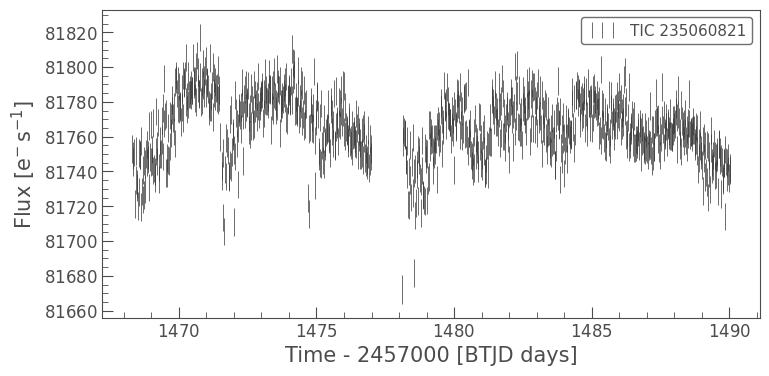

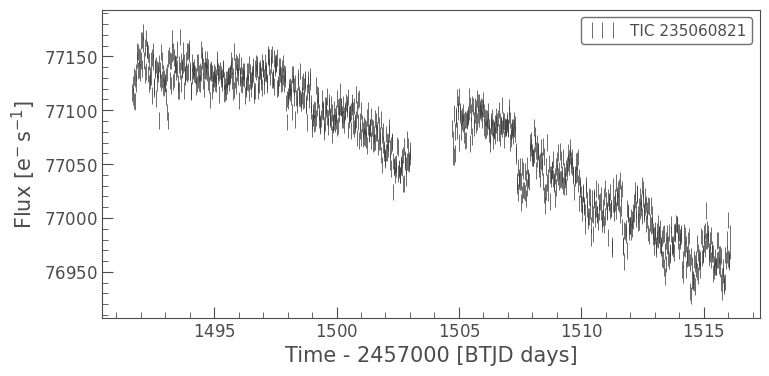

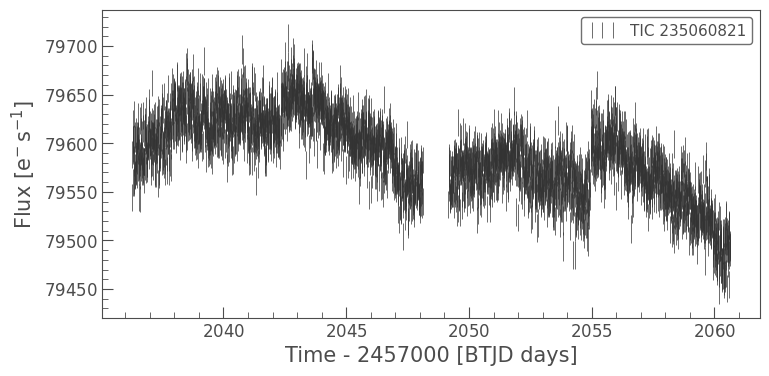

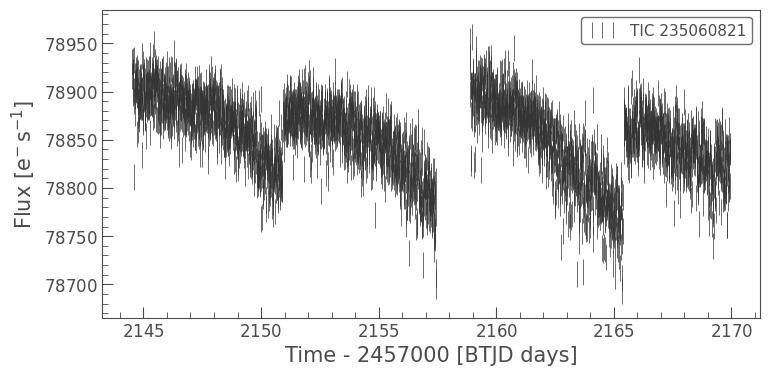

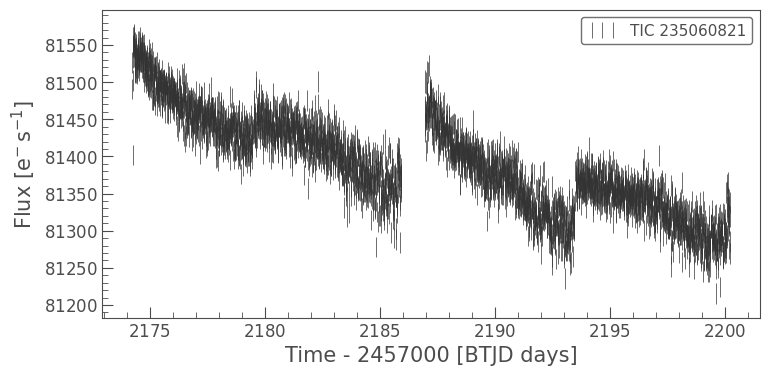

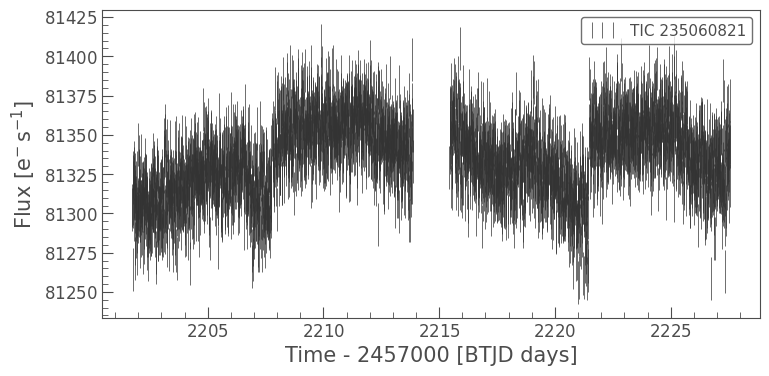

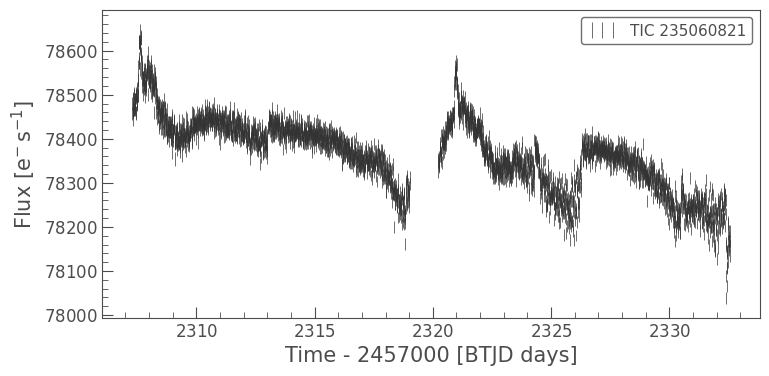

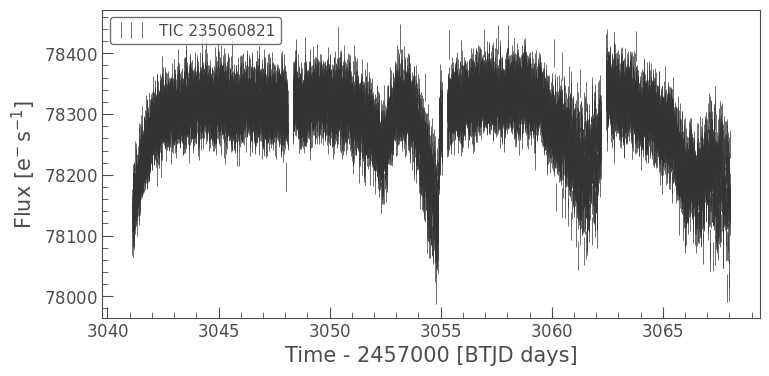

In [20]:
search_result = lightkurve.search_targetpixelfile(f'TIC {star_id}', mission = 'TESS', cadence = 'long')
pixel_files = search_result[:10].download_all()

collection = lightkurve.LightCurveCollection(None)
for pixel_file in pixel_files[:]:
    pixel_file = pixel_file[numpy.isfinite(pixel_file.flux).all(axis = (1, 2))]
    pixel_file = pixel_file[numpy.isfinite(pixel_file.flux_err).all(axis = (1, 2))]

    lc = PLDCorrector(pixel_file).correct()
    # lc = pixel_file.to_lightcurve(aperture_mask = pixel_file.pipeline_mask)

    lc.errorbar()
    collection.append(lc)

plot.show()

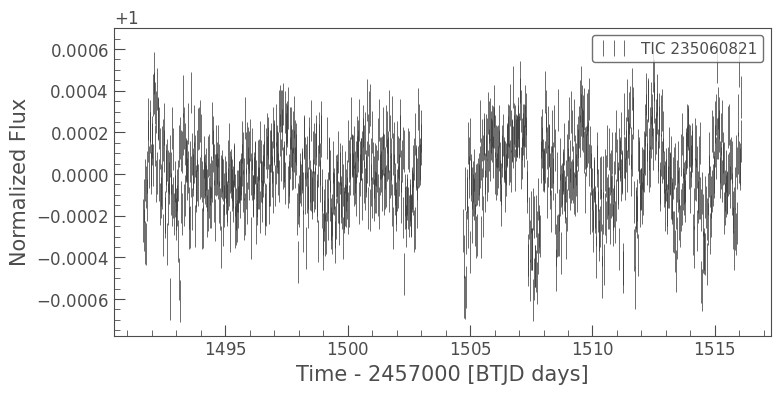

In [34]:
lc = collection[3:4].stitch().normalize()
lc = lc.flatten(window_length = 501, break_tolerance = 10, niters = 1, sigma = 10).remove_outliers(sigma = 10)
# lc = lc.remove_outliers(sigma = 5)
lc.errorbar()
# plot.gca().set_xlim(1507, 1509)
# plot.gca().set_ylim(0.999, 1.0005)
plot.show()

In [59]:
period = triceratops['period']
duration = triceratops['transit_duration'] / 24
transit_time = triceratops['transit_time']
depth = triceratops['transit_depth']
sectors = [7]
exptime = 1800 / 86400

In [ ]:
# import pandas

# url = 'https://stev.oapd.inaf.it/tmp/output603559110852.dat'

# data = pandas.read_csv('trilegal.tbl', delim_whitespace = True, comment = '#')
# data

In [ ]:
# data.to_csv('trilegal.csv')

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

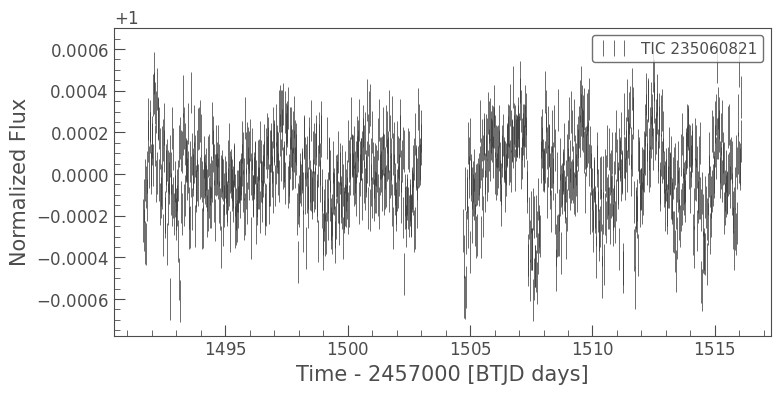

In [35]:
lc.errorbar()

In [ ]:
# depth += -0.005 # add extra depth after seeing folded to improve value

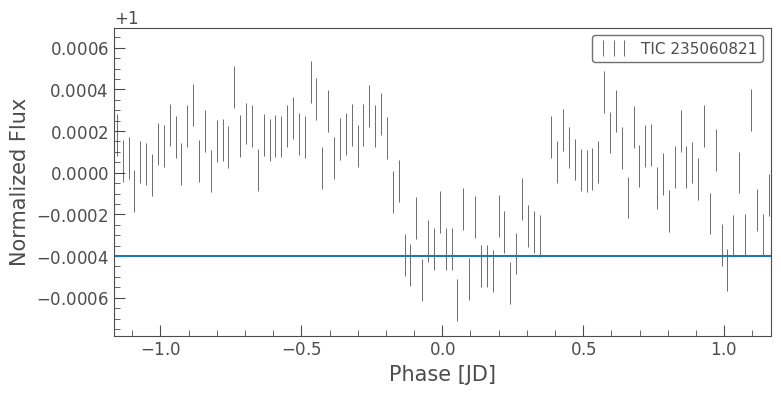

In [60]:
lc = lc.normalize()
period = period if period is not None else 100
flc = lc.fold(period = period, epoch_time = transit_time)
flc.errorbar()
plot.hlines([1 - depth], flc.time.min().value, flc.time.max().value)
plot.xlim(-duration * 2, duration * 2)
plot.show()

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

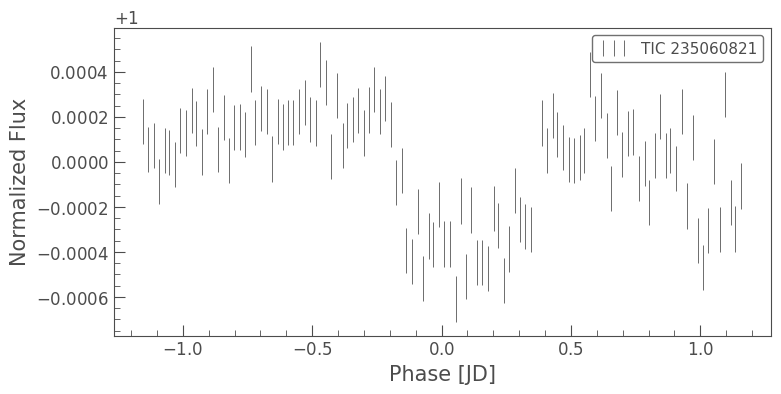

In [ ]:
mask = numpy.abs(flc.time) < duration * 2
mflc = flc[mask]
blc = mflc.bin(time_bin_size = (2 * duration * 2) / 512)
blc.errorbar()

In [38]:
target = tr.target(ID = star_id, search_radius = 5, sectors = numpy.array(sectors), trilegal_fname = None)

Getting TessCut for sector 7


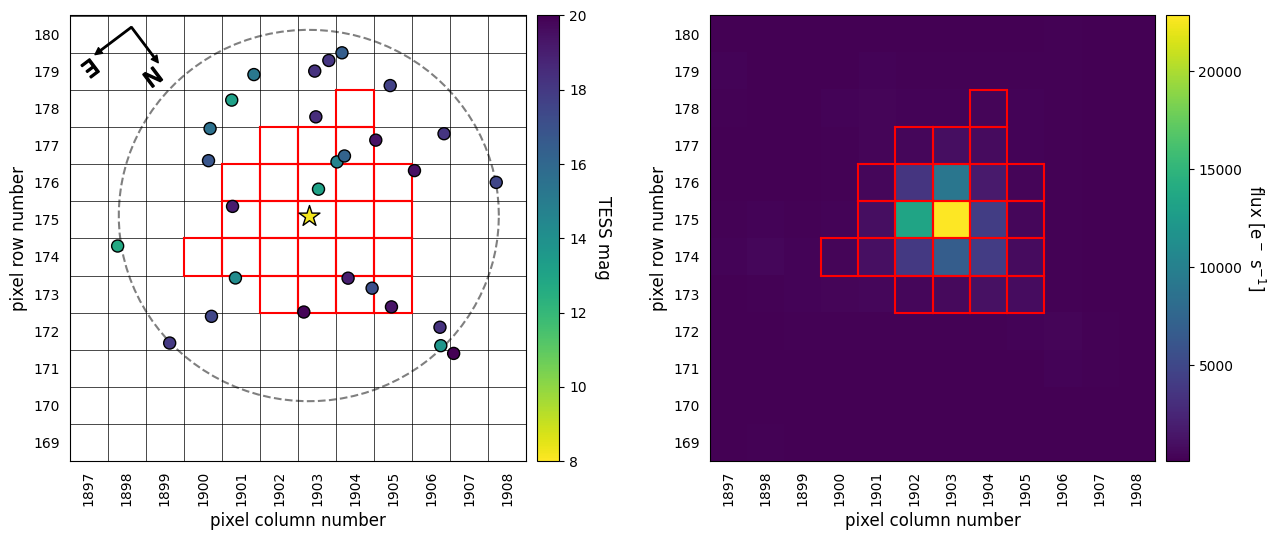

In [39]:
aps = target.get_spoc_apertures()
target.plot_field(sector = sectors[0], ap_pixels = aps[0] if aps != [] else None, ap_color = 'red')

In [40]:
target.stars

,ID,Tmag,Jmag,Hmag,Kmag,ra,dec,mass,rad,Teff,plx,sep (arcsec),PA (E of N)
0,235060821,8.2240,7.773,7.542,7.475,83.592212,-51.631711,1.300000,2.080520,6436.0,6.508320,0.000,0.000
1,235060823,13.0846,12.245,11.751,11.672,83.586635,-51.633976,NaN,4.722260,5134.0,0.435255,14.892,236.806
2,235060824,14.6379,14.032,13.688,13.724,83.579262,-51.635673,1.070000,0.967228,5906.0,0.828390,32.261,243.756
3,734596089,18.9829,NaN,NaN,NaN,83.593603,-51.621574,NaN,NaN,NaN,0.517976,36.628,4.867
4,235060825,16.2132,15.628,15.129,15.058,83.576995,-51.635779,1.120000,0.782249,6032.0,0.452536,37.021,246.692
5,734596087,19.1015,NaN,NaN,NaN,83.605436,-51.638567,NaN,NaN,3585.0,1.636680,38.499,129.876
6,235060812,17.1397,16.449,16.245,15.831,83.590448,-51.618600,1.060000,0.714765,5878.0,0.249940,47.365,355.224
7,734596090,19.8999,NaN,NaN,NaN,83.606814,-51.621088,NaN,NaN,NaN,3.435480,50.273,40.479
8,235060819,14.2011,13.634,13.284,13.295,83.615014,-51.630188,1.150000,1.429100,6119.0,0.639089,51.248,83.865
9,235060828,18.4547,16.475,16.016,15.869,83.576900,-51.642423,NaN,NaN,NaN,NaN,51.550,221.573


In [41]:
target.calc_depths(tdepth = depth, all_ap_pixels = aps)

In [42]:
target.stars[target.stars.tdepth > 0]

,ID,Tmag,Jmag,Hmag,Kmag,ra,dec,mass,rad,Teff,plx,sep (arcsec),PA (E of N),fluxratio,tdepth
0,235060821,8.2240,7.773,7.542,7.475,83.592212,-51.631711,1.30,2.080520,6436.0,6.508320,0.000,0.000,0.982918,0.000407
1,235060823,13.0846,12.245,11.751,11.672,83.586635,-51.633976,NaN,4.722260,5134.0,0.435255,14.892,236.806,0.011019,0.036300
2,235060824,14.6379,14.032,13.688,13.724,83.579262,-51.635673,1.07,0.967228,5906.0,0.828390,32.261,243.756,0.002395,0.167022
4,235060825,16.2132,15.628,15.129,15.058,83.576995,-51.635779,1.12,0.782249,6032.0,0.452536,37.021,246.692,0.000530,0.754558
8,235060819,14.2011,13.634,13.284,13.295,83.615014,-51.630188,1.15,1.429100,6119.0,0.639089,51.248,83.865,0.002047,0.195430


In [73]:
target.calc_probs(
    time = blc.time.value,                               # binned time data
    flux_0 = blc.flux.value,                             # binned flux data
    flux_err_0 = numpy.mean(blc.flux_err.value),            # standard deviation of (out-of-transit) flux data
    P_orb = 1,                              # best-fit orbital period of planet candidate
    contrast_curve_file = None,        # contrast curve file to use (str)
    filt = 'TESS',                                # number of instances to simulate for each scenario (int, usually fine to leave alone)
    parallel = True,                               # whether or not to use parallel processing (bool)
    # drop_scenario = ['DTP', 'DEB', 'DEBx2P', 'BTP', 'BEB', 'BEBx2P', 'NTP', 'NEB', 'NEB2xP'],
    verbose = 1,                                   # whether or not to print updates (0 or 1)
    flatpriors = False,                            # whether or not to assume flat planet priors (bool)
    exptime = exptime,                             # exposure time of TESS data (float, in days)
    molusc_file = None
)

Calculating TP scenario probabilitiey for 235060821.
Calculating EB and EBx2P scenario probabilities for 235060821.
Calculating PTP scenario probability for 235060821.
Calculating PEB and PEBx2P scenario probabilities for 235060821.
Calculating STP scenario probability for 235060821.
Calculating SEB and SEBx2P scenario probabilities for 235060821.
Calculating DTP scenario probability for 235060821.
Calculating DEB and DEBx2P scenario probabilities for 235060821.
Calculating BTP scenario probability for 235060821.
Calculating BEB and BEBx2P scenario probabilities for 235060821.
Calculating NTP, NEB, and NEB2xP scenario probabilities for 235060823.
Calculating NTP, NEB, and NEB2xP scenario probabilities for 235060824.
Calculating NTP, NEB, and NEB2xP scenario probabilities for 235060825.
Calculating NTP, NEB, and NEB2xP scenario probabilities for 235060819.


In [74]:
target.probs

,ID,scenario,M_s,R_s,P_orb,inc,b,ecc,w,R_p,M_EB,R_EB,prob
0,235060821,TP,1.300000,2.080520,1.0,54.481135,1.303857,0.329736,201.959173,1.657598,0.000000,0.000000,NaN
1,235060821,EB,1.300000,2.080520,1.0,73.830440,0.792067,0.028495,299.499758,0.000000,1.284877,1.433263,NaN
2,235060821,EBx2P,1.300000,2.080520,2.0,88.555289,0.091960,0.000927,189.226129,0.000000,0.165237,0.197215,NaN
3,235060821,PTP,1.300000,2.080520,1.0,58.065330,1.157035,0.009560,72.598509,5.270339,0.000000,0.000000,NaN
4,235060821,PEB,1.300000,2.080520,1.0,80.648303,0.449901,0.000018,277.126751,0.000000,1.264578,1.412012,NaN
5,235060821,PEBx2P,1.300000,2.080520,2.0,47.714303,3.098852,0.780462,233.268435,0.000000,1.295774,1.444541,NaN
6,235060821,STP,1.209154,1.351887,1.0,58.897166,1.051520,0.469099,35.242561,2.747939,0.000000,0.000000,NaN
7,235060821,SEB,0.180234,0.211715,1.0,16.845989,9.546418,0.459314,14.057152,0.000000,0.173054,0.204863,NaN
8,235060821,SEBx2P,0.180234,0.211715,2.0,16.845989,15.153993,0.459314,14.057152,0.000000,0.173054,0.204863,NaN
9,235060821,DTP,1.300000,2.080520,1.0,23.398478,1.903076,0.060841,94.354246,3.716224,0.000000,0.000000,NaN


In [75]:
print('FPP = ', target.FPP) # eb on this star, etc.
print('NFPP = ', target.NFPP) # nearby contamination

FPP =  nan
NFPP =  0.0


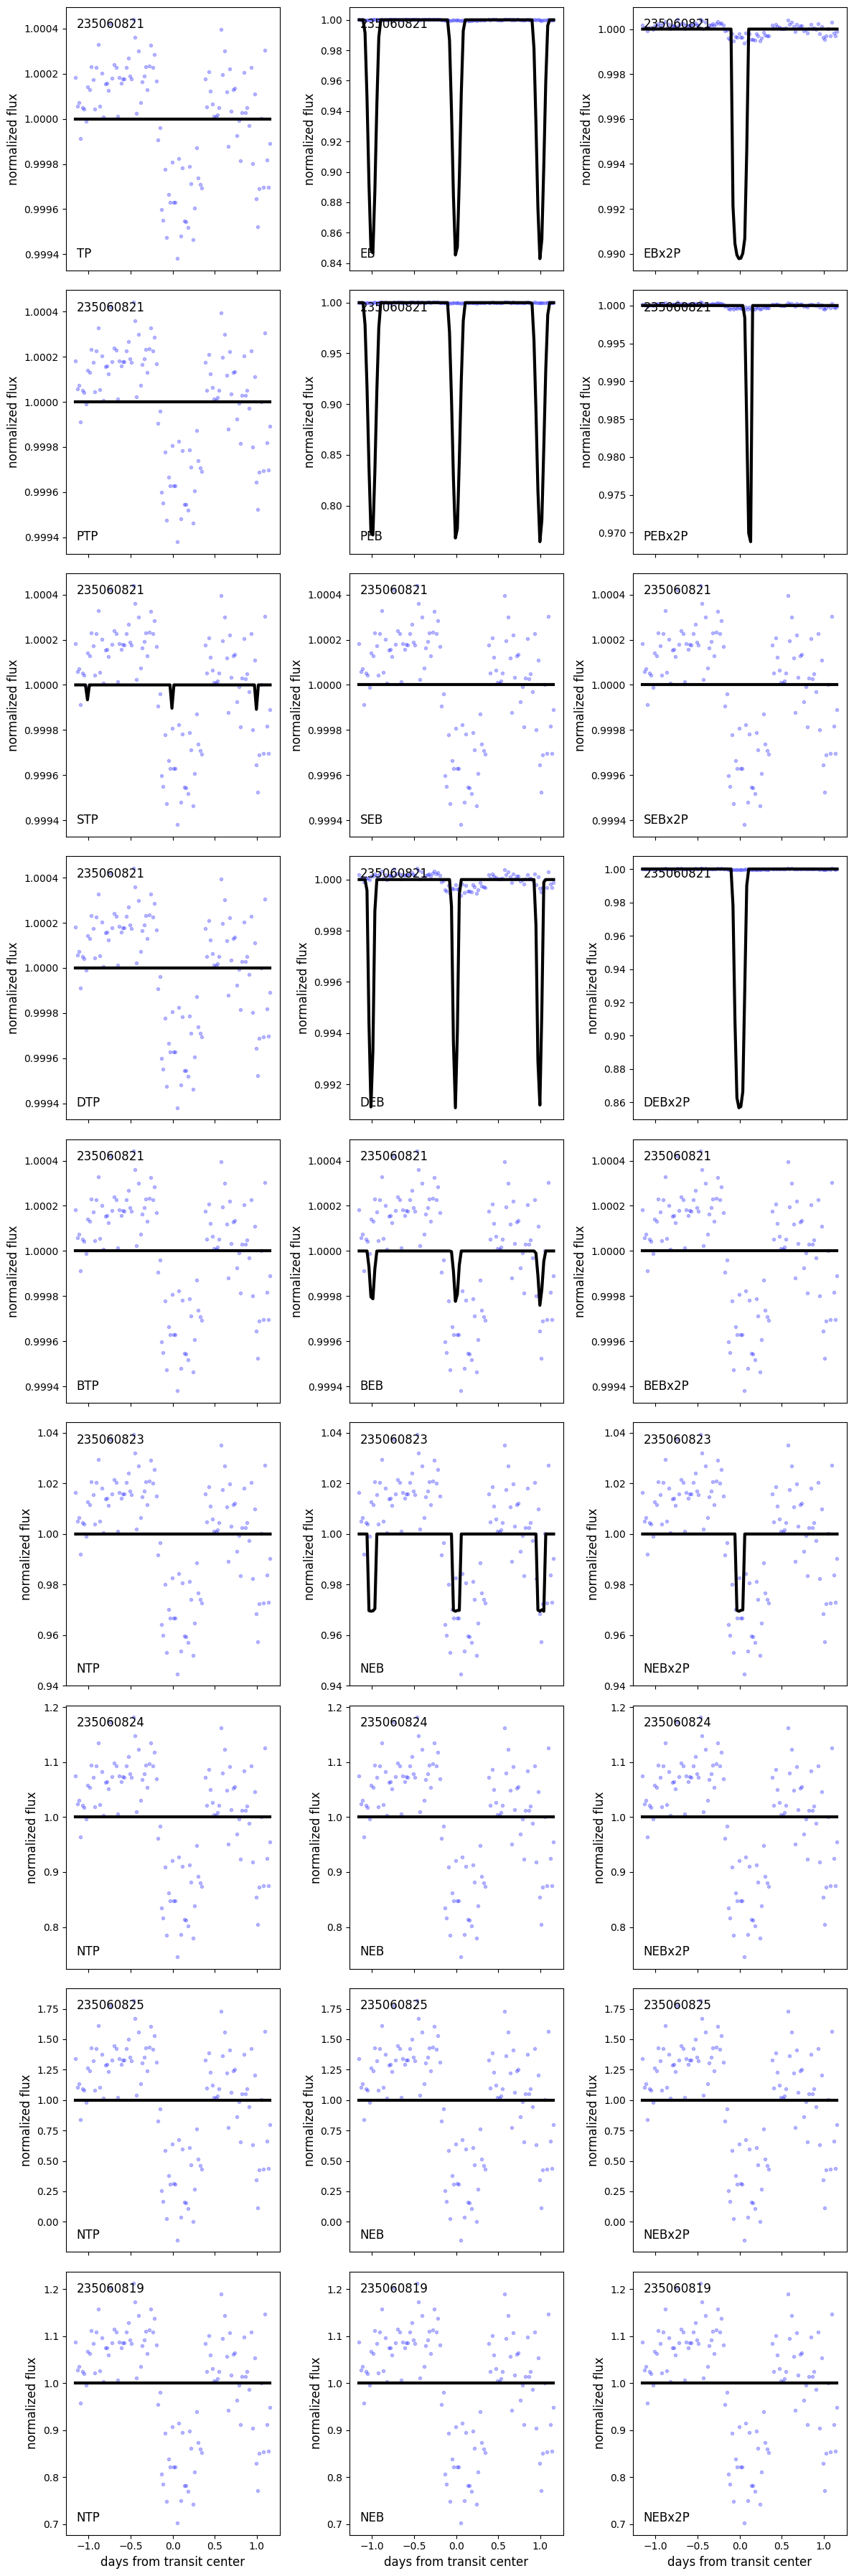

In [76]:
target.plot_fits(
    time = blc.time.value,                               # binned time data
    flux_0 = blc.flux.value,                             # binned flux data
    flux_err_0 = numpy.mean(blc.flux_err.value)
)